[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2021 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

WIP...
The project is currently under heavy development while adding new material for the summer semester 2021

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 7 Sampling Reconstruction Filters

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def my_sinc(x):  # we rather use definition sinc(x) = sin(x)/x, thus:
    return np.sinc(x/np.pi)

Assume ideal Dirac comb sampling with $h_s(t) = \frac{1}{T} {\bot \!\! \bot \!\! \bot}(\frac{t}{T}) = \sum_{m=-\infty}^{+\infty} \delta(t-m T)$ and reconstruction with the following reconstruction filters.

**Ideal lowpass** 

\begin{equation}
h_{ideal}(t) = \mathrm{sinc}(a t) \circ - \bullet H_{ideal}(\omega) = \frac{\pi}{|a|} \mathrm{rect}(\frac{\omega}{2 a})
\end{equation} 

For $a = \frac{\pi}{T} > 0$, we get

\begin{equation}
h_{ideal}(t) = \mathrm{sinc}(\frac{\pi t}{T}) \circ - \bullet H_{ideal}(\omega) = T \mathrm{rect}(\frac{\omega T}{2 \pi}) = T \mathrm{rect}(\frac{\omega}{\omega_s}),
\end{equation} 

for which the passband $|\omega|<\frac{\omega_s}{2} = \frac{\frac{2\pi}{T}}{2} = \frac{\pi}{T}$ holds.

**Spline 0th order** (nearest neighbor, zero order hold)

\begin{equation}
h_{r0}(t) = \mathrm{rect}(a t) \circ-\bullet H_{r0}(\omega) = \frac{1}{|a|} \mathrm{sinc}(\frac{\omega}{2 a})
\end{equation}

For $a = \frac{1}{T} > 0$, we get

\begin{equation}
h_{r0}(t) = \mathrm{rect}(\frac{t}{T}) \circ-\bullet H_{r0}(\omega) = T \mathrm{sinc}(\frac{\omega T}{2}).
\end{equation}

**Spline 1st order** (linear)

\begin{equation}
h_{r1}(t) = \Lambda(a t) \circ-\bullet H_{r1}(\omega) = \frac{1}{|a|} \mathrm{sinc}^2(\frac{\omega}{2 a})
\end{equation}

For $a = \frac{1}{T} > 0$, we get

\begin{equation}
h_{r1}(t) = \Lambda(\frac{t}{T}) \circ-\bullet H_{r1}(\omega) = T \mathrm{sinc}^2(\frac{\omega T}{2})
\end{equation}

ws/2 =  2.5446900725644124 rad/s
ws   =  5.089380145128825 rad/s


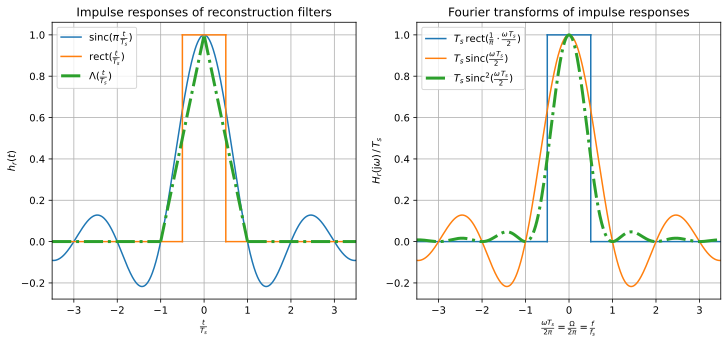

In [2]:
N = 3.5  # plot range

Ts = 1.23456789  # sampling intervall in s, dont care since we plot normalized

fs = 1/Ts  # samping frequency in Hz
ws = 2*np.pi/Ts  # angular sampling frequency in rad/s
print('ws/2 = ', ws/2, 'rad/s')
print('ws   = ', ws, 'rad/s')

t = np.arange(-N*Ts, N*Ts, Ts/100)
hsinc = my_sinc(np.pi*t/Ts)

w = np.arange(-N*ws, +N*ws, ws/100)
Hsinc = Ts * my_sinc(Ts*w/2) / Ts  # spline 0th order
Hsinc2 = Ts * my_sinc(Ts*w/2)**2 / Ts  # spline 1st order

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t/Ts, hsinc, 'C0', label=r'$\mathrm{sinc}(\pi\,\frac{t}{T_s})$')
plt.plot((t[0]/Ts, -(Ts/2)/Ts), (0, 0), 'C1')
plt.plot((+(Ts/2)/Ts, t[-1]/Ts), (0, 0), 'C1')
plt.plot((-(Ts/2)/Ts, -(Ts/2)/Ts), (0, 1), 'C1')
plt.plot((+(Ts/2)/Ts, +(Ts/2)/Ts), (0, 1), 'C1')
plt.plot((-(Ts/2)/Ts, +(Ts/2)/Ts), (1, 1), 'C1',
         label=r'$\mathrm{rect}(\frac{t}{T_s})$')
plt.plot((t[0]/Ts, -(Ts)/Ts), (0, 0), 'C2-.', lw=3)
plt.plot((+(Ts)/Ts, t[-1]/Ts), (0, 0), 'C2-.', lw=3)
plt.plot((-(Ts)/Ts, 0), (0, 1), 'C2-.', lw=3)
plt.plot((+(Ts)/Ts, 0), (0, 1), 'C2-.', lw=3, label=r'$\Lambda(\frac{t}{T_s})$')
plt.xlabel(r'$\frac{t}{T_s}$')
plt.ylabel(r'$h_r(t)$')
plt.title('Impulse responses of reconstruction filters')
plt.xlim(t[0]/Ts, t[-1]/Ts)
plt.legend(loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot((w[0]/ws, -np.pi/Ts / ws), (0, 0), 'C0')
plt.plot((+np.pi/Ts / ws, w[-1]/ws), (0, 0), 'C0')
plt.plot((-np.pi/Ts / ws, -np.pi/Ts / ws), (0, Ts/Ts), 'C0')
plt.plot((+np.pi/Ts / ws, +np.pi/Ts / ws), (0, Ts/Ts), 'C0')
plt.plot((-np.pi/Ts / ws, +np.pi/Ts / ws), (Ts/Ts, Ts/Ts), 'C0',
         label=r'$T_s\,\mathrm{rect}(\frac{1}{\pi}\cdot\frac{\omega\,T_s}{2})$')
plt.plot(w/ws, Hsinc, 'C1',
         label=r'$T_s\,\mathrm{sinc}(\frac{\omega\,T_s}{2})$')
plt.plot(w/ws, Hsinc2, 'C2-.',
         label=r'$T_s\,\mathrm{sinc}^2(\frac{\omega\,T_s}{2})$', lw=3)
plt.xlabel(
    r'$\frac{\omega T_s}{2 \pi} = \frac{\Omega}{2 \pi} = \frac{f}{f_s}$')
plt.ylabel(r'$H_r(\mathrm{j}\omega)\,/\,T_s$')
plt.title('Fourier transforms of impulse responses')
plt.xlim(w[0]/ws, w[-1]/ws)
plt.legend(loc='upper left')
plt.grid(True)

plt.savefig('ReconstructionSplines.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``main file, github URL, commit number and/or version tag, year``.